> **Installing Pytorch**: [Getting Started](https://pytorch.org/get-started/locally/) with PyTorch

# Training a Neural Network
- It **learns** how to map `training examples` to `targets`: This is what NNs do, feed it with data and the answers, it comes up with rules after learning patterns, and then it predicts answers.

_Example use case: Wondermovies organization seeking to predict the number of hours their users will spend on their platform watching movies in the coming week._

**Steps in building an nn would include**:
- **Data preparation:** prepare a tensor containing input and output data
- **Creating learnable parameters:** tensors containing random values, that will be optimized to solve the problem
- **Network Model:** a function that produces output for the input data, applying a linear rule, multiplying weights with input data and adding the bias term: `y = Wx + b`
- **Loss:** provides information about how good the model is
- **Optimizer:** helps with adjusing random weights created initially to help model calculate target values more accurately

```python
x,y = get_data()                  # where x represents training data and y represents target variables

w,b = get_weights()               # w,b are the learnable parameters

for i in range(500):
    y_pred = simple_network(x)    # function which computes wx + b
    loss = loss_fn(y, y_pred)     # calculates the sum of the squared differences of y and y_pred
    if i % 50 == 0:
        print(loss)
        optimize(learning_rate)   # adjust w,b to minimize the loss
```

## Data Preparations
Data abstractions in PyTorch are: `Tensors` and `variables`
- **Tensors**: n-dimensional python arrays. they are similar to numpy arrays and can be used on GPUs (for increased performance)
  - Scalar (0-D tensors)
  - Vector (1-D tensors)
  - Matrix (2-D tensors)
  - 3-D tensors
  - Slicing tensors
  - 4-D tensors
  - 5-D tensors
  - Tensors on GPU

In [16]:
import torch

### Scalar: 0-D
A tensor containing no axes and has only one numerical value

In [31]:
s = torch.tensor(7)
print(s)
print(s.ndim, "-D tensor")
print(s.size())
print(s.shape)

tensor(7)
0 -D tensor
torch.Size([])
torch.Size([])


### Vectors: 1-D
An array of elements.

In [32]:
v = torch.FloatTensor([37.3, 35.6, 37.6, 36.7, 37.7, 35.0])
print(v)
print(v.ndim, "-D tensor")
print(v.size())
print(v.shape)

tensor([37.3000, 35.6000, 37.6000, 36.7000, 37.7000, 35.0000])
1 -D tensor
torch.Size([6])
torch.Size([6])


### Matrix: 2-D
A rectangular grid or 2-dimensional array of number arranged in rows and columns

In [33]:
M = torch.tensor([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])
print(M)
print(M.ndim, "-D tensor")
print(M.size())
print(M.shape)

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
2 -D tensor
torch.Size([3, 3])
torch.Size([3, 3])


### 3-D Tensors
Adding multiple matrices together creates a 3-D matrixe.g image data (224, 224, 3)

In [38]:
D3 = torch.tensor([
    [
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]
    ],
    [
        [3, 2, 1],
        [6, 5, 4],
        [9, 8, 7]
    ],
    [
        [7, 8, 9],
        [4, 5, 6],
        [1, 2, 3]
    ]
])
print(D3)
print(D3.ndim, "-D tensor")
print(D3.size())
print(D3.shape)

tensor([[[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]],

        [[3, 2, 1],
         [6, 5, 4],
         [9, 8, 7]],

        [[7, 8, 9],
         [4, 5, 6],
         [1, 2, 3]]])
3 -D tensor
torch.Size([3, 3, 3])
torch.Size([3, 3, 3])


In [51]:
from PIL import Image
import numpy as np

# load image
img = np.array(Image.open("../../data/messi.jpg").resize((224, 224)))
img_tensor = torch.from_numpy(img)
print(img_tensor.ndim, "-D tensor")
print(img_tensor.size())
print(img_tensor.shape)

3 -D tensor
torch.Size([224, 224, 3])
torch.Size([224, 224, 3])


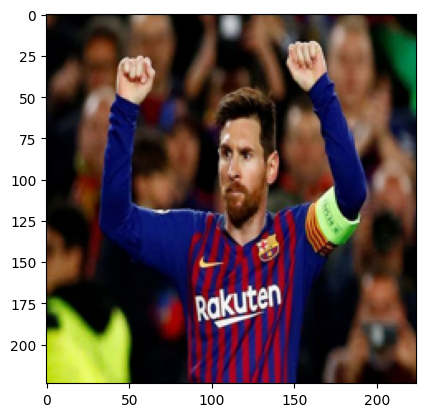

In [52]:
import matplotlib.pyplot as plt

# view image
plt.imshow(img)

### SLICING TENSORS
A common thing to do is to subset a tensor. e.g selecting the first five elements of a 1-D tensor

In [56]:
sales = torch.tensor([1000.0, 300.0, 457., 800., 3455.0, 432.6, 100.2, 566.7, 700.4])

# first five elements in sales
print(sales[:5])

# sales without its last five elements
print(sales[:-5])

tensor([1000.,  300.,  457.,  800., 3455.])
tensor([1000.,  300.,  457.,  800.])


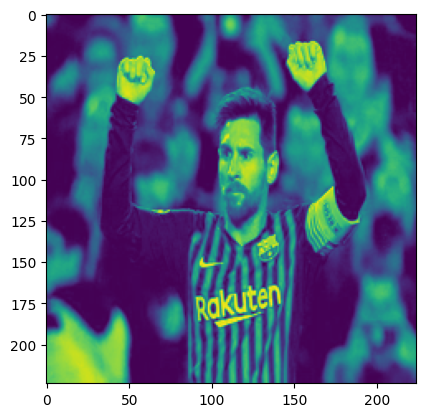

In [60]:
# try on image data
plt.imshow(img_tensor[:,:,0]) # first layer

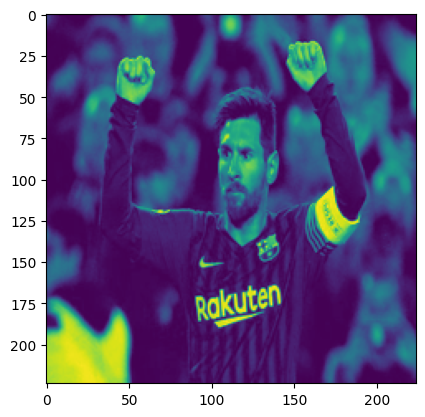

In [61]:
plt.imshow(img_tensor[:,:,1]) # second layer

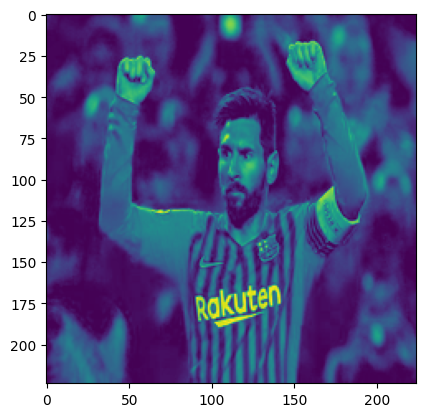

In [62]:
plt.imshow(img_tensor[:,:,2]) # third layer

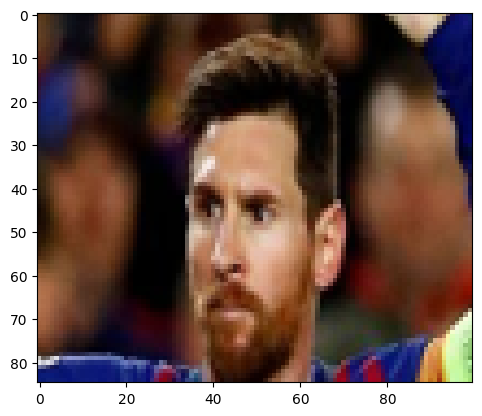

In [64]:
# subset head
plt.imshow(img_tensor[40:125, 70:170,:])